# Modeling Identifikasi Suara Buka Tutup

# Hasil Aplikasi

# https://t7fqkvcqvlww9inpxuubnx.streamlit.app/

In [1]:
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
import sounddevice as sd
import soundfile as sf
from IPython.display import Audio, display
import pickle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

# Path ke dataset utama
dataset_path = "dataset48k/train"
output_csv = "dataset48k_output/metadata_features.csv"

# List untuk menampung data
data = []

# Loop folder 'buka' dan 'tutup'
for label in ["buka", "tutup"]:
    folder = os.path.join(dataset_path, label)
    for filename in tqdm(os.listdir(folder), desc=f"Processing {label}"):
        if filename.endswith(".wav"):
            file_path = os.path.join(folder, filename)
            
            # Load audio
            y, sr = librosa.load(file_path, sr=48000)
            
            # Ekstraksi fitur dasar
            mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).T, axis=0)
            zcr = np.mean(librosa.feature.zero_crossing_rate(y))
            spec_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
            spec_bw = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
            rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
            
            # Gabungkan semua fitur ke 1 baris
            features = np.hstack([mfccs, zcr, spec_centroid, spec_bw, rolloff])
            
            # Tambahkan ke list data
            data.append([label, file_path] + list(features))

# Buat DataFrame
columns = ["label", "file_path"] + [f"mfcc_{i}" for i in range(1, 14)] + ["zcr", "centroid", "bandwidth", "rolloff"]
df = pd.DataFrame(data, columns=columns)

# Simpan ke CSV
df.to_csv(output_csv, index=False)
print(f"✅ Fitur disimpan ke {output_csv}")


Processing buka:   0%|                                                                                                                  | 0/150 [00:00<?, ?it/s]

Processing buka:   1%|▋                                                                                                         | 1/150 [00:02<06:36,  2.66s/it]

Processing buka:   2%|██                                                                                                        | 3/150 [00:02<01:49,  1.34it/s]

Processing buka:   3%|███▌                                                                                                      | 5/150 [00:02<00:56,  2.55it/s]

Processing buka:   5%|████▉                                                                                                     | 7/150 [00:03<00:35,  3.99it/s]

...

Processing tutup:  97%|████████████████████████████████████████████████████████████████████████████████████████████████████▎  | 146/150 [00:09<00:00, 13.74it/s]

Processing tutup:  99%|█████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 148/150 [00:09<00:00, 13.76it/s]

Processing tutup: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:09<00:00, 14.15it/s]

Processing tutup: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:09<00:00, 15.13it/s]

✅ Fitur disimpan ke dataset48k_output/metadata_features.csv


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Baca CSV hasil ekstraksi
data = pd.read_csv("dataset48k_output/metadata_features.csv")

# Pisahkan fitur dan label
X = data.drop(columns=["label", "file_path"])
y = data["label"]

# Bagi train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Normalisasi fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data latih: {len(X_train)}, data uji: {len(X_test)}")


✅ Data latih: 240, data uji: 60


k=1 → Akurasi: 100.00%
k=3 → Akurasi: 100.00%
k=5 → Akurasi: 100.00%
k=7 → Akurasi: 100.00%
k=9 → Akurasi: 100.00%


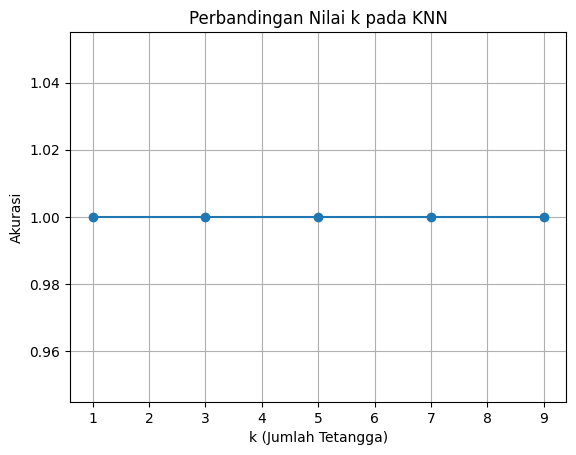

In [4]:
k_values = [1, 3, 5, 7, 9]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"k={k} → Akurasi: {acc*100:.2f}%")

plt.plot(k_values, accuracies, marker='o')
plt.title("Perbandingan Nilai k pada KNN")
plt.xlabel("k (Jumlah Tetangga)")
plt.ylabel("Akurasi")
plt.grid(True)
plt.show()

Akurasi Model KNN (k=5): 100.00% 


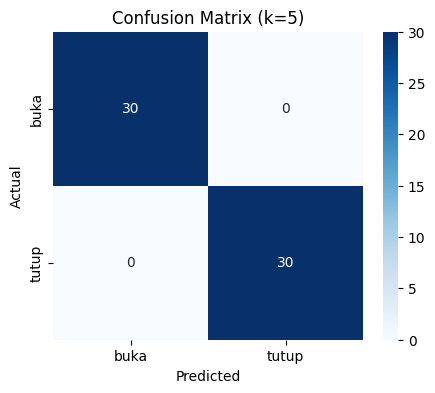

Classification Report:
              precision    recall  f1-score   support

        buka       1.00      1.00      1.00        30
       tutup       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [5]:
best_k = 5

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Akurasi Model KNN (k={best_k}): {acc*100:.2f}% ")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["buka", "tutup"])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["buka","tutup"], yticklabels=["buka","tutup"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (k={best_k})")
plt.show()

# Laporan detail (precision, recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["buka","tutup"]))

In [6]:
with open("model_knn_buka_tutup.pkl", "wb") as f:
    pickle.dump(knn_model, f)

with open("scaler_buka_tutup.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [7]:
import librosa
import numpy as np
import pandas as pd
import pickle
from IPython.display import Audio, display

# ────────────────────────────────
# 1️⃣ Muat model dan scaler
# ────────────────────────────────
model = pickle.load(open("model_knn_buka_tutup.pkl", "rb"))
scaler = pickle.load(open("scaler_buka_tutup.pkl", "rb"))

# ────────────────────────────────
# 2️⃣ Tentukan file audio yang mau diuji
# ────────────────────────────────
file_path = "dataset48k/val/tutup/tutup48k-tutup_151.wav.wav"   # ganti sesuai file kamu
sr = 48000  # karena dataset48k → 48 kHz

# ────────────────────────────────
# 3️⃣ Load dan tampilkan audio
# ────────────────────────────────
y, _ = librosa.load(file_path, sr=sr)
display(Audio(data=y, rate=_))

# ────────────────────────────────
# 4️⃣ Preprocessing audio (trim & normalisasi)
# ────────────────────────────────
y_trimmed, _ = librosa.effects.trim(y, top_db=20)
y_norm = y_trimmed / np.max(np.abs(y_trimmed))

# ────────────────────────────────
# 5️⃣ Ekstraksi fitur (sama seperti waktu training)
# ────────────────────────────────
def extract_features(y, sr):
    mean = np.mean(y)
    std = np.std(y)
    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return {
        "mean": mean,
        "std": std,
        "rms": rms,
        "zcr": zcr,
        "centroid": centroid,
        "bandwidth": bandwidth,
        "contrast": contrast,
        "rolloff": rolloff
    }

feat = extract_features(y_norm, sr)
feat_df = pd.DataFrame([feat])

# ────────────────────────────────
# 6️⃣ Normalisasi fitur menggunakan scaler
# ────────────────────────────────
feat_scaled = scaler.transform(feat_df)

# ────────────────────────────────
# 7️⃣ Prediksi label dan probabilitas
# ────────────────────────────────
pred = model.predict(feat_scaled)[0]
prob = model.predict_proba(feat_scaled)[0]
classes = model.classes_

# ────────────────────────────────
# 8️⃣ Tampilkan hasil prediksi
# ────────────────────────────────
print("\n🎧 Hasil Klasifikasi:")
print("--------------------------")
print("Prediksi :", pred)
print("\nProbabilitas:")
for cls, p in zip(classes, prob):
    print(f"{cls}: {p*100:.2f}%")


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- contrast
- mean
- rms
- std
Feature names seen at fit time, yet now missing:
- mfcc_1
- mfcc_10
- mfcc_11
- mfcc_12
- mfcc_13
- ...


In [19]:
import streamlit as st
import sounddevice as sd
import numpy as np
import librosa
import joblib
import pandas as pd

# ───────────────────────────────
# 1️⃣ Load model & scaler
# ───────────────────────────────
model = joblib.load("model_knn.pkl")
scaler = joblib.load("scaler.pkl")

# ───────────────────────────────
# 2️⃣ Load metadata (untuk ambil struktur fitur)
# ───────────────────────────────
data = pd.read_csv("dataset48k_output/metadata_features.csv")
st.sidebar.success("📁 Metadata loaded!")
st.sidebar.write(f"Total data: {len(data_train)}")

# ───────────────────────────────
# 3️⃣ Fungsi rekam suara dari mic
# ───────────────────────────────
def record_audio(duration=2, sr=22050):
    st.info("🎙️ Merekam suara... Silakan ucapkan 'buka' atau 'tutup'")
    audio = sd.rec(int(duration * sr), samplerate=sr, channels=1, dtype='float32')
    sd.wait()
    st.success("✅ Rekaman selesai!")
    return np.squeeze(audio), sr

# ───────────────────────────────
# 4️⃣ Ekstraksi fitur audio
# ───────────────────────────────
def extract_features(y, sr):
    feat = {
        "zcr": np.mean(librosa.feature.zero_crossing_rate(y)),
        "chroma_stft": np.mean(librosa.feature.chroma_stft(y=y, sr=sr)),
        "rms": np.mean(librosa.feature.rms(y=y)),
        "spectral_centroid": np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
        "spectral_bandwidth": np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)),
        "spectral_rolloff": np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)),
    }

    # Tambahkan 13 MFCC
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        feat[f"mfcc_{i+1}"] = np.mean(mfccs[i])
    return feat

# ───────────────────────────────
# 5️⃣ UI Streamlit
# ───────────────────────────────
st.title("🎧 Deteksi Suara Buka / Tutup (Real-time Mic Test)")
st.write("Klik tombol di bawah untuk merekam suara dan deteksi apakah 'Buka' atau 'Tutup'.")

duration = st.slider("Durasi rekaman (detik)", 1, 5, 2)

if st.button("🎤 Mulai Rekam"):
    audio, sr = record_audio(duration)
    feat = extract_features(audio, sr)

    # Ubah ke DataFrame
    feat_df = pd.DataFrame([feat])
    feat_scaled = scaler.transform(feat_df)

    # Prediksi
    probs = model.predict_proba(feat_scaled)[0]
    pred = model.predict(feat_scaled)[0]

    label = "🔊 **BUKA**" if pred == 0 else "🤫 **TUTUP**"

    st.subheader(f"Hasil Prediksi: {label}")
    st.write(f"Probabilitas Buka: {probs[0]:.4f}")
    st.write(f"Probabilitas Tutup: {probs[1]:.4f}")


2025-11-10 08:02:05.223 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2025-11-10 08:02:05.292 
  command:

    streamlit run C:\Users\Jordan\AppData\Roaming\Python\Python39\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-11-10 08:02:05.293 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-10 08:02:05.293 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-10 08:02:05.294 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-10 08:02:05.296 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-10 08:02:05.296 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-10 08:02:05.297 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-10 08:02:05.298 Thread 'MainThread': missing ScriptRunContext! This warning can be ig

In [20]:
import os
import joblib
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import librosa
import glob

# Dataset path
train_buka = sorted(glob.glob("dataset48k/train/buka/*.wav"))
train_tutup = sorted(glob.glob("dataset48k/train/tutup/*.wav"))

X = []
y = []

# Ekstraksi fitur MFCC
for file in train_buka:
    audio, sr = librosa.load(file, sr=48000)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)
    X.append(np.mean(mfcc.T, axis=0))
    y.append(0)  # label 0 = buka

for file in train_tutup:
    audio, sr = librosa.load(file, sr=48000)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)
    X.append(np.mean(mfcc.T, axis=0))
    y.append(1)  # label 1 = tutup

# Ubah ke numpy array
X = np.array(X)
y = np.array(y)

# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Latih model KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

# Simpan model dan scaler
joblib.dump(knn, "model_knn.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Model dan scaler berhasil disimpan!")


✅ Model dan scaler berhasil disimpan!


In [ ]:
import streamlit as st
import sounddevice as sd
import numpy as np
import librosa
import pandas as pd
import joblib
import time

# ───────────────────────────────
# 1️⃣ Load model & scaler
# ───────────────────────────────
model = joblib.load("model_knn.pkl")
scaler = joblib.load("scaler.pkl")

# ───────────────────────────────
# 2️⃣ Load struktur fitur
# ───────────────────────────────
data_train = pd.read_csv("dataset48k_output/metadata.csv")
expected_features = data_train.drop(columns=["label", "file_path"]).columns


# ───────────────────────────────
# 3️⃣ UI Streamlit
# ───────────────────────────────
st.title("🎙️ Deteksi Suara Buka / Tutup Mulut")
st.write("Klik tombol di bawah ini untuk merekam suara kamu...")

duration = st.slider("Durasi rekaman (detik)", 1, 5, 2)

if st.button("🎧 Rekam Sekarang"):
    st.info("Merekam... silakan ucapkan **buka** atau **tutup**")
    sr = 22050
    audio = sd.rec(int(duration * sr), samplerate=sr, channels=1, dtype="float32")
    sd.wait()
    st.success("✅ Rekaman selesai!")

    # ───────────────────────────────
    # 4️⃣ Ekstraksi fitur audio
    # ───────────────────────────────
    y = np.squeeze(audio)

    feat = {
        "zcr": np.mean(librosa.feature.zero_crossing_rate(y)),
        "chroma_stft": np.mean(librosa.feature.chroma_stft(y=y, sr=sr)),
        "rms": np.mean(librosa.feature.rms(y=y)),
        "spectral_centroid": np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
        "spectral_bandwidth": np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)),
        "spectral_rolloff": np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)),
    }

    # Tambahkan 13 MFCC
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        feat[f"mfcc_{i+1}"] = np.mean(mfccs[i])

    feat_df = pd.DataFrame([feat])

    # Samakan fitur
    for col in expected_features:
        if col not in feat_df.columns:
            feat_df[col] = 0
    feat_df = feat_df[expected_features]

    # ───────────────────────────────
    # 5️⃣ Normalisasi & Prediksi
    # ───────────────────────────────
    feat_scaled = scaler.transform(feat_df)
    pred = model.predict(feat_scaled)[0]
    prob = model.predict_proba(feat_scaled)[0]

    # ───────────────────────────────
    # 6️⃣ Tampilkan Hasil
    # ───────────────────────────────
    st.subheader("🧠 Hasil Prediksi")
    st.markdown(f"### Suara kamu terdeteksi sebagai: **{pred.upper()}**")

    st.write("### Probabilitas:")
    prob_dict = {cls: f"{p*100:.2f}%" for cls, p in zip(model.classes_, prob)}
    st.json(prob_dict)

    # ───────────────────────────────
    # 7️⃣ (Opsional) Tampilkan waveform audio
    # ───────────────────────────────
    st.audio(np.int16(y * 32767), sample_rate=sr)


KeyError: "['file'] not found in axis"